<a href="https://colab.research.google.com/github/SohamBodhak/ML_notebooks/blob/main/Regression_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Project 1: Comprehensive Regression Analysis
### Course: Introduction to Machine Learning

This notebook is designed to guide you through a comprehensive regression analysis using various techniques. You will explore different methods, implement regularization techniques, and evaluate the performance of your models using various metrics and computational time.







### Team Name:PIKACHU
### Name and ID of Member 1: Soham Bodhak, B2430060
### Name and ID of Member 2: Prithwish Ganguly, B2430034

In [ ]:
!pip install ucimlrepo

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.datasets import make_regression
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import add_dummy_feature
# Add all other libraries you would require


## 1. Load the Dataset
**Instruction:** Load the chosen dataset and display its basic information and statistics. You may use any well-known dataset.

In [ ]:
# Loading a particular dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)

In [ ]:
X = pd.DataFrame(parkinsons_telemonitoring.data.features)
y = pd.DataFrame(parkinsons_telemonitoring.data.targets)["motor_UPDRS"]

df=pd.concat([X,y],axis=1)
y = pd.DataFrame(parkinsons_telemonitoring.data.targets)["total_UPDRS"]

df=pd.concat([df,y],axis=1)

df.drop(columns=['Jitter(Abs)', 'Jitter:RAP','Jitter:PPQ5','Jitter:DDP','Shimmer:APQ3','Shimmer:APQ5','Shimmer:APQ11','Shimmer:DDA','Shimmer(dB)'
                ,'age','test_time','Jitter(%)','Shimmer','NHR','HNR','RPDE','DFA','PPE','sex'], inplace=True)

df.head()

,motor_UPDRS,total_UPDRS
0,28.199,34.398
1,28.447,34.894
2,28.695,35.389
3,28.905,35.810
4,29.187,36.375


In [ ]:
#Display basic statistics
print(df.describe(include='all'))

       motor_UPDRS  total_UPDRS
count  5875.000000  5875.000000
mean     21.296229    29.018942
std       8.129282    10.700283
min       5.037700     7.000000
25%      15.000000    21.371000
50%      20.871000    27.576000
75%      27.596500    36.399000
max      39.511000    54.992000


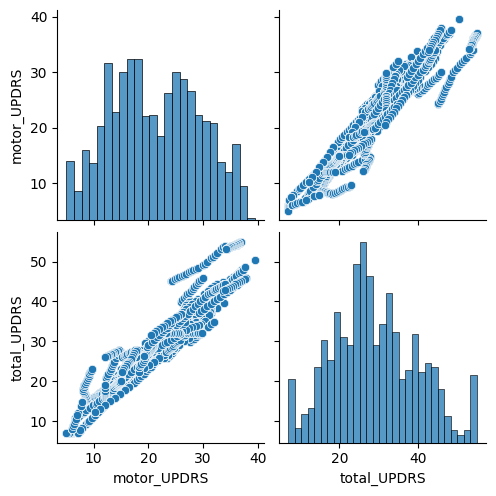

In [ ]:
sns.pairplot(df)
plt.show()

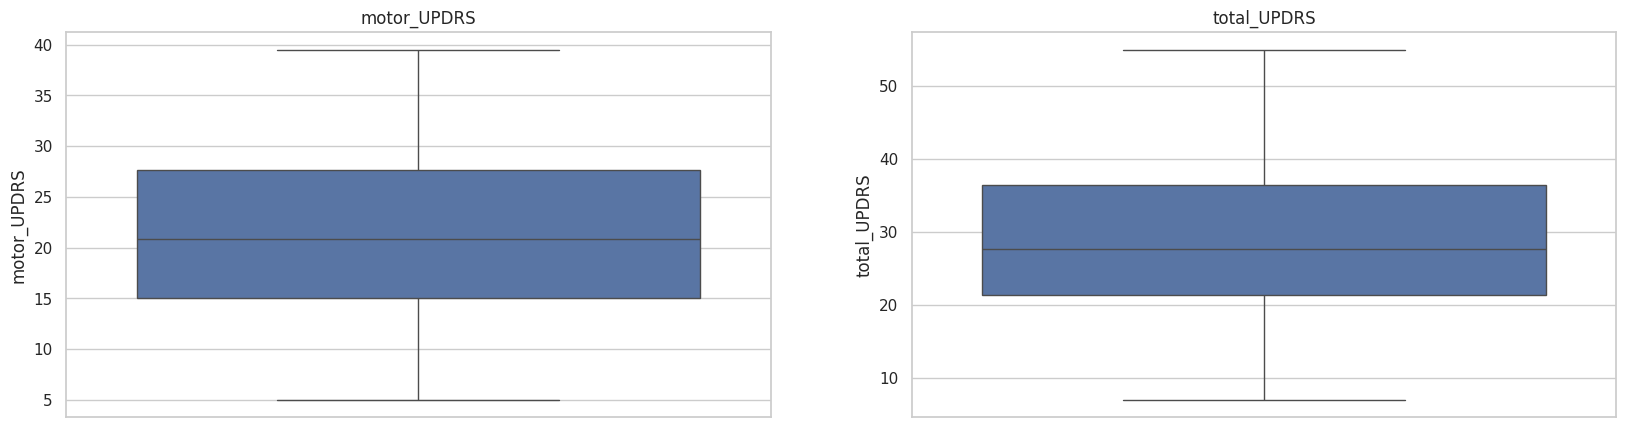

In [ ]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=len(df.columns), figsize=(20, 5))
for i, column in enumerate(df.columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(column)
plt.show()


## 2. Data Preprocessing
**Instruction:** Perform any necessary preprocessing steps, including handling missing values, encoding categorical variables, and scaling features if required.


In [ ]:
# Checking for missing values
print(df.isnull().sum())
# Split the dataset into features (X) and target (y)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()
X=scaler.fit_transform(X)

# Split the data into training and test sets (e.g., 80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=42,
                                   test_size=0.20,
                                   shuffle=True)
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
print(X.shape)

motor_UPDRS    0
total_UPDRS    0
dtype: int64
(5875, 1)



## 3. Simple Linear Regression
**Instruction:** Implement a simple linear regression model using scikit-learn.


Mean Squared Error (MSE) for test data: 11.344282886739126
----------------------------------------------------------------------
Mean Absolute Error (MAE) for test data: 2.55781551270386
----------------------------------------------------------------------
R-squared (R²) for test data: 0.897626826709514
----------------------------------------------------------------------
Mean Squared Error (MSE) for training data: 11.896581414231752
----------------------------------------------------------------------
Mean Absolute Error (MAE) for training data: 2.552360928007767
----------------------------------------------------------------------
R-squared (R²) for training data: 0.8968885115568784
----------------------------------------------------------------------


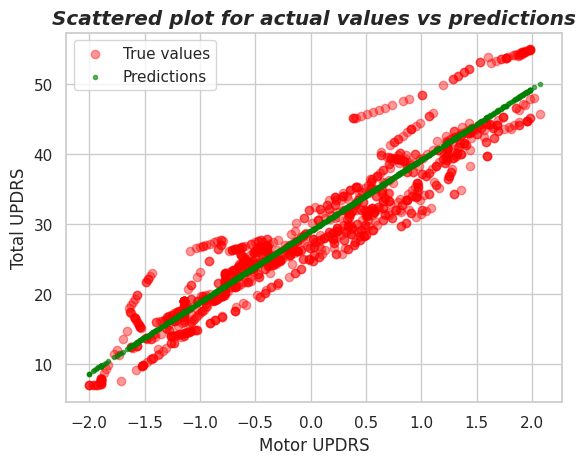

In [ ]:
# Define the linear regression model
model = LinearRegression()
# Fit the model on the training data
start=time.time()
model.fit(X_train,y_train)
end=time.time()
time_lin=end-start
# Predict on the test data
y_pred = model.predict(X_test)
# Calculate performance metrics [MSE, MAE, R^2]
mse_lin = mean_squared_error(y_test, y_pred)
mae_lin = mean_absolute_error(y_test, y_pred)
r2_lin = r2_score(y_test, y_pred)
mse_train=mean_squared_error(y_train,model.predict(X_train))
mae_train=mean_absolute_error(y_train,model.predict(X_train))
r2_train=r2_score(y_train,model.predict(X_train))
# Print the metrics
print("Mean Squared Error (MSE) for test data:", mse_lin)
print("-"*70)
print("Mean Absolute Error (MAE) for test data:", mae_lin)
print("-"*70)
print("R-squared (R²) for test data:", r2_lin)
print("-"*70)
print("Mean Squared Error (MSE) for training data:", mse_train)
print("-"*70)
print("Mean Absolute Error (MAE) for training data:", mae_train)
print("-"*70)
print("R-squared (R²) for training data:", r2_train)
print("-"*70)
plt.scatter( X_test , y_test , color = 'red' , label="True values" , marker="o" , alpha=0.4)
plt.scatter(X_test , y_pred , color = 'green' , label="Predictions" , marker=".", alpha=0.6)
plt.grid(True)
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.title("Scattered plot for actual values vs predictions" , fontsize='large',fontweight='bold',style='italic')
plt.legend()
plt.show()


## 4. Polynomial Regression
**Instruction:** Implement polynomial regression for degrees 2, 3, and 4.


Mean Squared Error (MSE) for Polynomial of degree 2: 11.120567275235588
----------------------------------------------------------------------
Mean Absolute Error (MAE) for Polynomial of degree 2: 2.5240214155480407
----------------------------------------------------------------------
R-squared (R²) for Polynomial of degree 2: 0.8996456830173913
----------------------------------------------------------------------


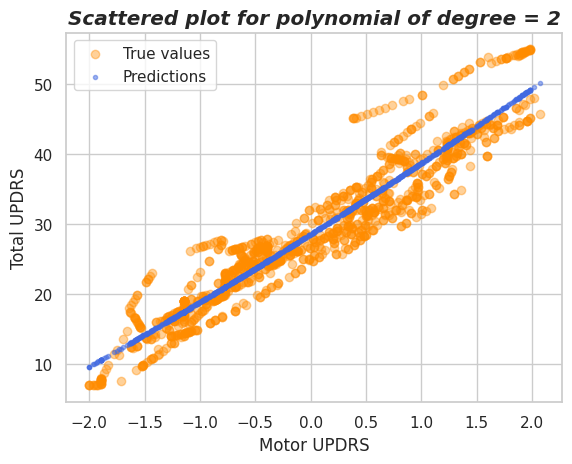

Mean Squared Error (MSE) for Polynomial of degree 3: 10.74827444947533
----------------------------------------------------------------------
Mean Absolute Error (MAE) for Polynomial of degree 3: 2.457099070676988
----------------------------------------------------------------------
R-squared (R²) for Polynomial of degree 3: 0.903005331075085
----------------------------------------------------------------------


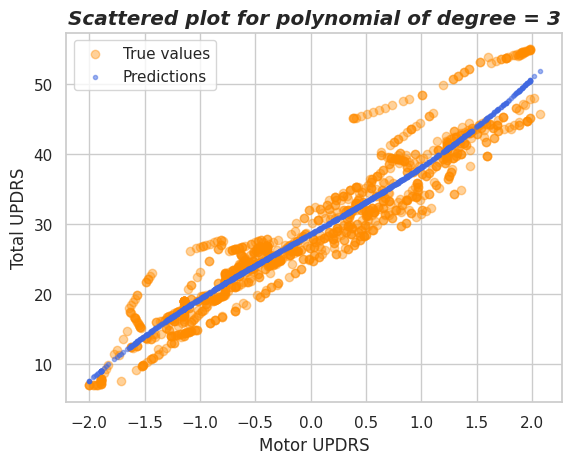

Mean Squared Error (MSE) for Polynomial of degree 4: 10.763274561302259
----------------------------------------------------------------------
Mean Absolute Error (MAE) for Polynomial of degree 4: 2.459815132392725
----------------------------------------------------------------------
R-squared (R²) for Polynomial of degree 4: 0.9028699669394435
----------------------------------------------------------------------


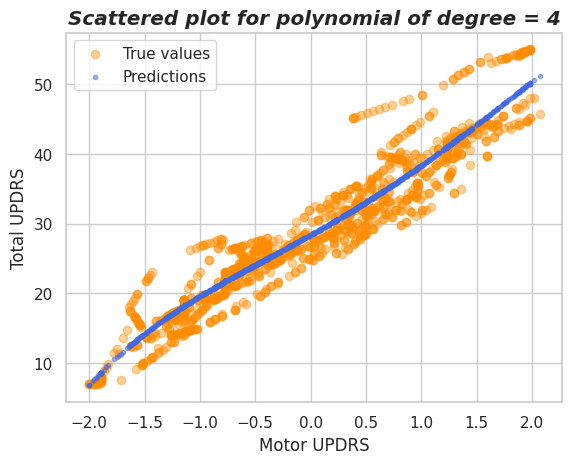

In [ ]:
# Define polynomial features
poly2=PolynomialFeatures(degree=2 , include_bias=False)
poly3=PolynomialFeatures(degree=3 , include_bias=False)
poly4=PolynomialFeatures(degree=4 , include_bias=False)


# Split the transformed data into training and test sets
X_poly_2 = poly2.fit_transform(X)
X_poly_3 = poly3.fit_transform(X)
X_poly_4 = poly4.fit_transform(X)
X_train_poly_2, X_test_poly_2, y_train, y_test =train_test_split(X_poly_2,y , random_state=42,  test_size=0.20,  shuffle=True)
X_train_poly_3, X_test_poly_3, y_train, y_test =train_test_split(X_poly_3,y , random_state=42,  test_size=0.20,  shuffle=True)
X_train_poly_4, X_test_poly_4, y_train, y_test =train_test_split(X_poly_4,y , random_state=42,  test_size=0.20,  shuffle=True)

# Fit the linear model on polynomial features
#poly_features_2 = poly2.fit_transform(X_train_poly.reshape(-1, 1))

poly_reg_model_deg2 = LinearRegression()
start=time.time()
poly_reg_model_deg2.fit(X_train_poly_2, y_train)
end=time.time()
time_pdeg2=end-start
y_predicted_2 = poly_reg_model_deg2.predict(X_test_poly_2)
mse2 = mean_squared_error(y_test, y_predicted_2)
mae2 = mean_absolute_error(y_test, y_predicted_2)
r22 = r2_score(y_test, y_predicted_2)
# Print the metrics
print("Mean Squared Error (MSE) for Polynomial of degree 2:", mse2)
print("-"*70)
print("Mean Absolute Error (MAE) for Polynomial of degree 2:", mae2)
print("-"*70)
print("R-squared (R²) for Polynomial of degree 2:", r22)
print("-"*70)
#plot
plt.scatter(X_test , y_test , color = 'darkorange' , label="True values", marker="o" , alpha=0.4)
plt.scatter(X_test , y_predicted_2 , color = 'royalblue' , label="Predictions",marker="." , alpha=0.5)
plt.title("Scattered plot for polynomial of degree = 2" , fontsize='large',fontweight='bold',style='italic')
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.grid(True)
plt.legend()
plt.show()

#poly_features_3 = poly3.fit_transform(X_train_poly.reshape(-1, 1))
poly_reg_model_deg3 = LinearRegression()
start=time.time()
poly_reg_model_deg3.fit(X_train_poly_3, y_train)
end=time.time()
time_pdeg3=end-start
y_predicted_3 = poly_reg_model_deg3.predict(X_test_poly_3)
mse3 = mean_squared_error(y_test, y_predicted_3)
mae3 = mean_absolute_error(y_test, y_predicted_3)

r23 = r2_score(y_test, y_predicted_3)
# Print the metrics
print("Mean Squared Error (MSE) for Polynomial of degree 3:", mse3)
print("-"*70)
print("Mean Absolute Error (MAE) for Polynomial of degree 3:", mae3)
print("-"*70)
print("R-squared (R²) for Polynomial of degree 3:", r23)
print("-"*70)
#plot
plt.scatter(X_test , y_test , color = 'darkorange' , label="True values", marker="o" , alpha=0.4)
plt.scatter(X_test , y_predicted_3 , color = 'royalblue' , label="Predictions",marker="." , alpha=0.5)
plt.title("Scattered plot for polynomial of degree = 3" , fontsize='large',fontweight='bold',style='italic')
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.grid(True)
plt.legend()
plt.show()

#poly_features_4 = poly4.fit_transform(X_train_poly.reshape(-1, 1))
poly_reg_model_deg4 = LinearRegression()
start=time.time()
poly_reg_model_deg4.fit(X_train_poly_4, y_train)
end=time.time()
time_pdeg4=end-start
y_predicted_4 = poly_reg_model_deg4.predict(X_test_poly_4)
mse4 = mean_squared_error(y_test, y_predicted_4)
mae4 = mean_absolute_error(y_test, y_predicted_4)
r24 = r2_score(y_test, y_predicted_4)
# Print the metrics
print("Mean Squared Error (MSE) for Polynomial of degree 4:", mse4)
print("-"*70)
print("Mean Absolute Error (MAE) for Polynomial of degree 4:", mae4)
print("-"*70)
print("R-squared (R²) for Polynomial of degree 4:", r24)
print("-"*70)
#plot
plt.scatter(X_test , y_test , color = 'darkorange' , label="True values", marker="o" , alpha=0.4)
plt.scatter(X_test , y_predicted_4 , color = 'royalblue' , label="Predictions",marker="." , alpha=0.5)
plt.title("Scattered plot for polynomial of degree = 4" , fontsize='large',fontweight='bold',style='italic')
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.grid(True)
plt.legend()
plt.show()



In [ ]:
X_train=np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test=np.c_[np.ones((X_test.shape[0], 1)), X_test]


## 5. Gradient Descent Methods
**Instruction:** Implement batch, stochastic, and mini-batch gradient descent for linear regression.


[[29.07647353]
 [10.17247877]]
Mean Squared Error (MSE) for test data: 11.344282852367018
----------------------------------------------------------------------
Mean Absolute Error (MAE) for test data: 2.557815502452408
----------------------------------------------------------------------
R-squared (R²) for test data: 0.8976268270196951
----------------------------------------------------------------------


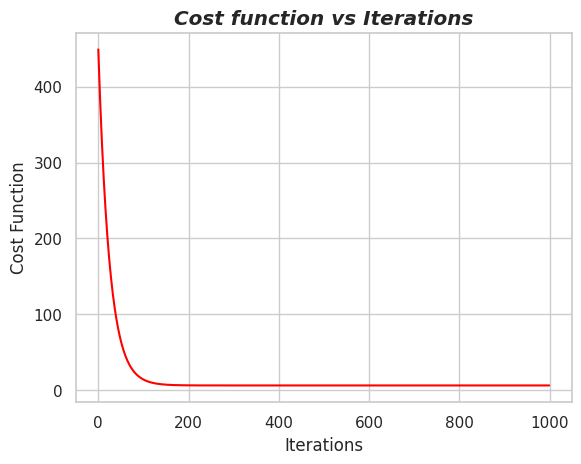

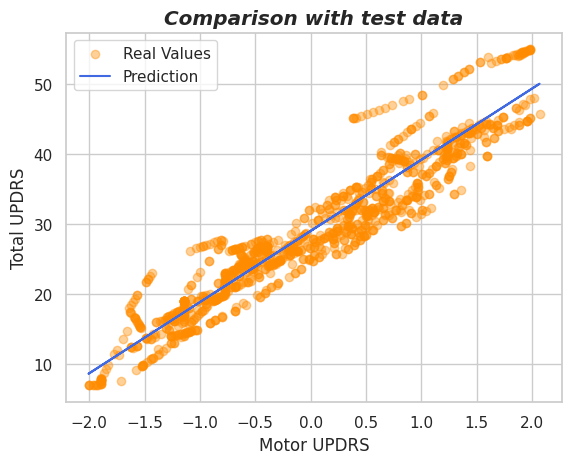

In [ ]:
# Example function for batch gradient descent.
# Return theta and history (a list that stores cost for each epoch)



def batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
     m=len(X)
     np.random.seed(42)
     theta=np.random.randn(X.shape[1],1)
     cost_hist=[]
     for epoch in range(epochs):
         gradients=2/m*X.T@(X@theta-np.array(y).reshape(-1,1))
         theta =theta-learning_rate*gradients
         predictions =X@theta
         cost =(1/(2*m))*np.sum((predictions -np.array(y).reshape(-1,1))**2)

         #cost=cost_(X,y,theta)
         cost_hist.append(cost)

     return theta , cost_hist
theta , cost_hist= batch_gradient_descent(X_train, y_train, learning_rate=0.01, epochs=1000)
print(theta)
Predictions = X_test.dot(theta)
mse = mean_squared_error(y_test, Predictions)
mae = mean_absolute_error(y_test, Predictions)
r2 = r2_score(y_test, Predictions)
print("Mean Squared Error (MSE) for test data:", mse)
print("-"*70)
print("Mean Absolute Error (MAE) for test data:", mae)
print("-"*70)
print("R-squared (R²) for test data:", r2)
print("-"*70)
epochs=1000
plt.plot(range(epochs) , cost_hist , label='Batch gradient Descent' , color ='red')

plt.title("Cost function vs Iterations" , fontsize='large',fontweight='bold',style='italic' )
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.show()

plt.scatter(X_test[: , 1] , y_test , label='Real Values' ,color="darkorange", marker="o" , alpha=0.4)
plt.plot(X_test[: , 1] , Predictions ,label='Prediction',color="royalblue")
plt.title("Comparison with test data", fontsize='large',fontweight='bold',style='italic')
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.legend()
plt.show()

Mean Squared Error (MSE) for test data: 11.3160807523378
----------------------------------------------------------------------
Mean Absolute Error (MAE) for test data: 2.5480345482559303
----------------------------------------------------------------------
R-squared (R²) for test data: 0.8978813286486012
----------------------------------------------------------------------


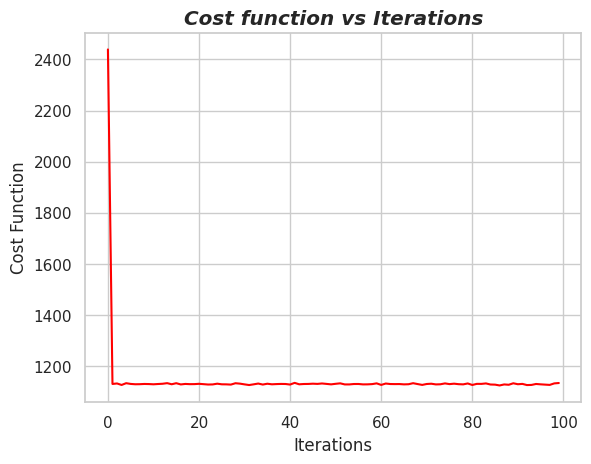

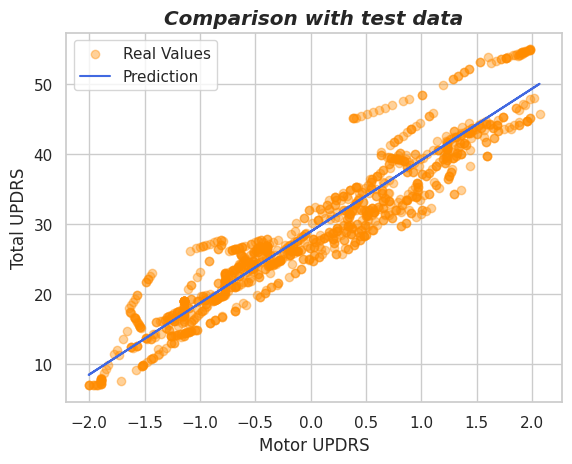

In [ ]:
# Example function for mini batch gradient descent.
# Return theta and history (a list that stores cost for each epoch)
def mini_batch_gradient_descent(X, y, batch_size =25, learning_rate=0.1, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)
    num_batches = int(np.ceil(m / batch_size))
    cost_hist=[]
    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y.iloc[indices]
        epoch_cost=0

        for batch_start in range(0, m, batch_size):
            batch_end = min(batch_start + batch_size, m)
            X_batch = X_shuffled[batch_start:batch_end]
            y_batch = y_shuffled[batch_start:batch_end]
            predictions = X_batch.dot(theta)
            errors = predictions - y_batch
            gradient = (2 / batch_size) * X_batch.T.dot(errors)
            theta -= learning_rate * gradient
            predictions =X@theta
            cost =np.mean(errors**2)/2
            epoch_cost+=cost
        cost_hist.append(epoch_cost)#/(m/batch_size))
    return theta, cost_hist
theta , cost_hist = mini_batch_gradient_descent(X_train, y_train, batch_size =25, learning_rate=0.1, epochs=100)
#print(mini_batch_gradient_descent(X, y, batch_size =25, learning_rate=0.1, epochs=1000))
Predictions = X_test.dot(theta)
mse = mean_squared_error(y_test, Predictions)
mae = mean_absolute_error(y_test, Predictions)
r2 = r2_score(y_test, Predictions)
print("Mean Squared Error (MSE) for test data:", mse)
print("-"*70)
print("Mean Absolute Error (MAE) for test data:", mae)
print("-"*70)
print("R-squared (R²) for test data:", r2)
print("-"*70)
epochs=100
plt.plot(range(epochs) , cost_hist , label='Mini batch gradient descent' , color ='red')

plt.title("Cost function vs Iterations" , fontsize='large',fontweight='bold',style='italic' )
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.show()

plt.scatter(X_test[: , 1] , y_test , label='Real Values' ,color="darkorange", marker="o" , alpha=0.4)
plt.plot(X_test[: , 1] , Predictions ,label='Prediction',color="royalblue")
plt.title("Comparison with test data", fontsize='large',fontweight='bold',style='italic')
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.legend()
plt.show()

Mean Squared Error (MSE) for test data: 12.131682605870848
----------------------------------------------------------------------
Mean Absolute Error (MAE) for test data: 2.710243599983462
----------------------------------------------------------------------
R-squared (R²) for test data: 0.8905211675241477
----------------------------------------------------------------------


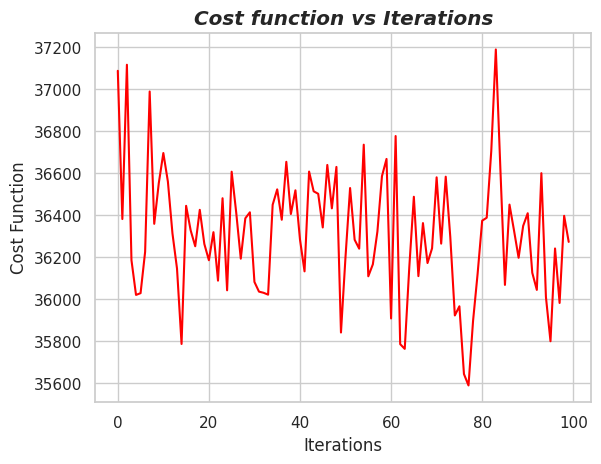

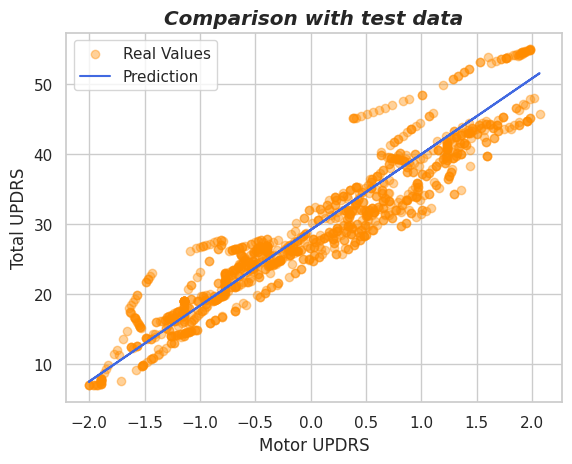

In [ ]:
# Example function for stochastic batch gradient descent.
# Return theta and history (a list that stores cost for each epoch)
def stochastic_gradient_descent(X, y, batch_size =1, learning_rate=0.1, epochs=100):
    m, n = X.shape
    theta = np.zeros(n)
    num_batches = int(np.ceil(m / batch_size))
    cost_hist=[]
    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y.iloc[indices]
        epoch_cost=0

        for batch_start in range(0, m, batch_size):
            batch_end = min(batch_start + batch_size, m)
            X_batch = X_shuffled[batch_start:batch_end]
            y_batch = y_shuffled[batch_start:batch_end]
            predictions = X_batch.dot(theta)
            errors = predictions - y_batch
            gradient = (2 / batch_size) * X_batch.T.dot(errors)
            theta -= learning_rate * gradient
            predictions =X@theta
            cost =np.mean(errors**2)/2
            epoch_cost+=cost
        cost_hist.append(epoch_cost)#/(m/batch_size))
    return theta, cost_hist
theta , cost_hist = stochastic_gradient_descent(X_train, y_train, batch_size =1, learning_rate=0.1, epochs=100)
#print(mini_batch_gradient_descent(X, y, batch_size =25, learning_rate=0.1, epochs=1000))
Predictions = X_test.dot(theta)
mse = mean_squared_error(y_test, Predictions)
mae = mean_absolute_error(y_test, Predictions)
r2 = r2_score(y_test, Predictions)
print("Mean Squared Error (MSE) for test data:", mse)
print("-"*70)
print("Mean Absolute Error (MAE) for test data:", mae)
print("-"*70)
print("R-squared (R²) for test data:", r2)
print("-"*70)
epochs=100
plt.plot(range(epochs) , cost_hist , label='Mini batch gradient descent' , color ='red')

plt.title("Cost function vs Iterations" , fontsize='large',fontweight='bold',style='italic' )
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.show()

plt.scatter(X_test[: , 1] , y_test , label='Real Values' ,color="darkorange", marker="o" , alpha=0.4)
plt.plot(X_test[: , 1] , Predictions ,label='Prediction',color="royalblue")
plt.title("Comparison with test data", fontsize='large',fontweight='bold',style='italic')
plt.xlabel("Motor UPDRS")
plt.ylabel("Total UPDRS")
plt.legend()
plt.show()


## 6. Regularization Techniques (Ridge,  Lasso, Elastic Net Regression and Early Stopping)
**Instruction:** Implement Ridge, Lasso regression, Elastic Net Regression, and Early Stopping using scikit-learn and compare the results.


In [ ]:
# Ridge Regression

ridge = Ridge()
start=time.time()
ridge.fit(X_train, y_train)
end=time.time()
time_ridge=end-start
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
#print(f'Ridge Regression MSE: {mse_ridge}')

# Lasso Regression

lasso = Lasso()
start=time.time()
lasso.fit(X_train, y_train)
end=time.time()
time_lasso=end-start
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
#print(f'Lasso Regression MSE: {mse_lasso}')

# Elastic Net Regression

elastic_net = ElasticNet()
start=time.time()
elastic_net.fit(X_train, y_train)
end=time.time()
time_enet=end-start
y_pred_enet = elastic_net.predict(X_test)
mse_enet = mean_squared_error(y_test, y_pred_enet)
mae_enet = mean_absolute_error(y_test, y_pred_enet)
r2_enet = r2_score(y_test, y_pred_enet)
#print(f'Elastic Net Regression MSE: {mse_enet}')

# Early Stopping

sgd = SGDRegressor(penalty='elasticnet', early_stopping=True, validation_fraction=0.1, n_iter_no_change=5)
start=time.time()
sgd.fit(X_train, y_train)
end=time.time()
time_es=end-start
y_pred_sgd = sgd.predict(X_test)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)
#print(f'Elastic Net with Early Stopping MSE: {mse_sgd}')

# Calculate performance metrics for each of these

results = {
    'Ridge': mse_ridge,
    'Lasso': mse_lasso,
    'Elastic Net': mse_enet,
    'Elastic Net with Early Stopping': mse_sgd
}

# Print the performance metrics

for model, mse in results.items():
    print(f'{model} Regression MSE: {mse}')


Ridge Regression MSE: 11.3434520409893
Lasso Regression MSE: 11.958160866237371
Elastic Net Regression MSE: 23.775667561076425
Elastic Net with Early Stopping Regression MSE: 11.304132888547436



## 7. Normal Equation
**Instruction:** Implement the normal equation method for linear regression.


In [ ]:
# Define Normal equation. Inputs: X and y, Output: theta
def normal_equation(X, y):
    # Put your code and output accordingly
    #X_b = np.c_[np.ones((X.shape[0], 1)), X]
    #X_b=np.hstack([np.ones((X.shape[0],1)),X])
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

    return theta

# Use the normal equation to find theta
theta_ne = normal_equation(X_train, y_train)
print(theta_ne)

# Predict using the normal equation
#y_pred_ne =
#X_test_ne=np.hstack([np.ones((X_test.shape[0],1)),X_test])
y_pred_ne = X_test@( theta_ne)
print(y_pred_ne)

# Calculate and print the performance metrics
mse = mean_squared_error(y_test, y_pred_ne)
mae = mean_absolute_error(y_test, y_pred_ne)
r2 = r2_score(y_test, y_pred_ne)
# Print the metrics
print("Mean Squared Error (MSE):", mse)
print("-"*70)
print("Mean Absolute Error (MAE):", mae)
print("-"*70)
print("R-squared (R²):", r2)
print("-"*70)


[29.07647357 10.17247879]
[44.27076872 11.2626561  16.42967142 ... 25.06491892 21.24513973
 20.25836343]
Mean Squared Error (MSE): 11.344282886739135
----------------------------------------------------------------------
Mean Absolute Error (MAE): 2.557815512703863
----------------------------------------------------------------------
R-squared (R²): 0.8976268267095139
----------------------------------------------------------------------


## 8. Implement linear Regression using SVD


In [ ]:
# Define SVD equation. Inputs: X and y, Output: theta
def svd_equation(X, y):
    # Put your code and output accordingly
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    S_inv = np.diag(1 / S)

    theta = Vt.T @ S_inv @ U.T @ y
    return theta

# Use the SVD equation to find theta
theta_ne = svd_equation(X_train, y_train)
print(theta_ne)

# Predict using the SVD equation
#y_pred_ne =
#X_test_ne=np.hstack([np.ones((X_test.shape[0],1)),X_test])
y_pred_ne = X_test@( theta_ne)
print(y_pred_ne)

# Calculate and print the performance metrics
mse = mean_squared_error(y_test, y_pred_ne)
mae = mean_absolute_error(y_test, y_pred_ne)
r2 = r2_score(y_test, y_pred_ne)
# Print the metrics
print("Mean Squared Error (MSE):", mse)
print("-"*70)
print("Mean Absolute Error (MAE):", mae)
print("-"*70)
print("R-squared (R²):", r2)
print("-"*70)

[29.07647357 10.17247879]
[44.27076872 11.2626561  16.42967142 ... 25.06491892 21.24513973
 20.25836343]
Mean Squared Error (MSE): 11.344282886739135
----------------------------------------------------------------------
Mean Absolute Error (MAE): 2.557815512703863
----------------------------------------------------------------------
R-squared (R²): 0.8976268267095139
----------------------------------------------------------------------



## 9. Performance Metrics and Computational Analysis
**Instruction:** Compare the performance and computational time of all models implemented.


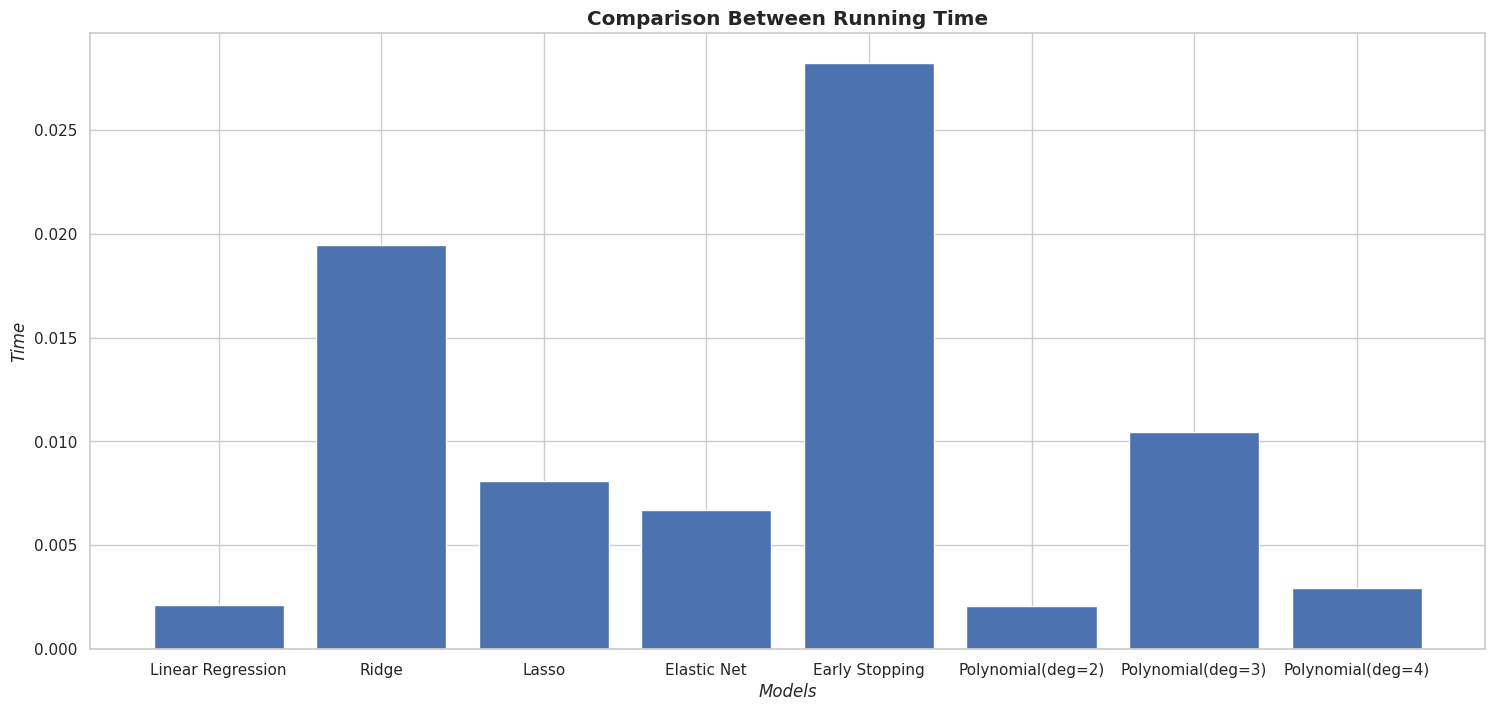

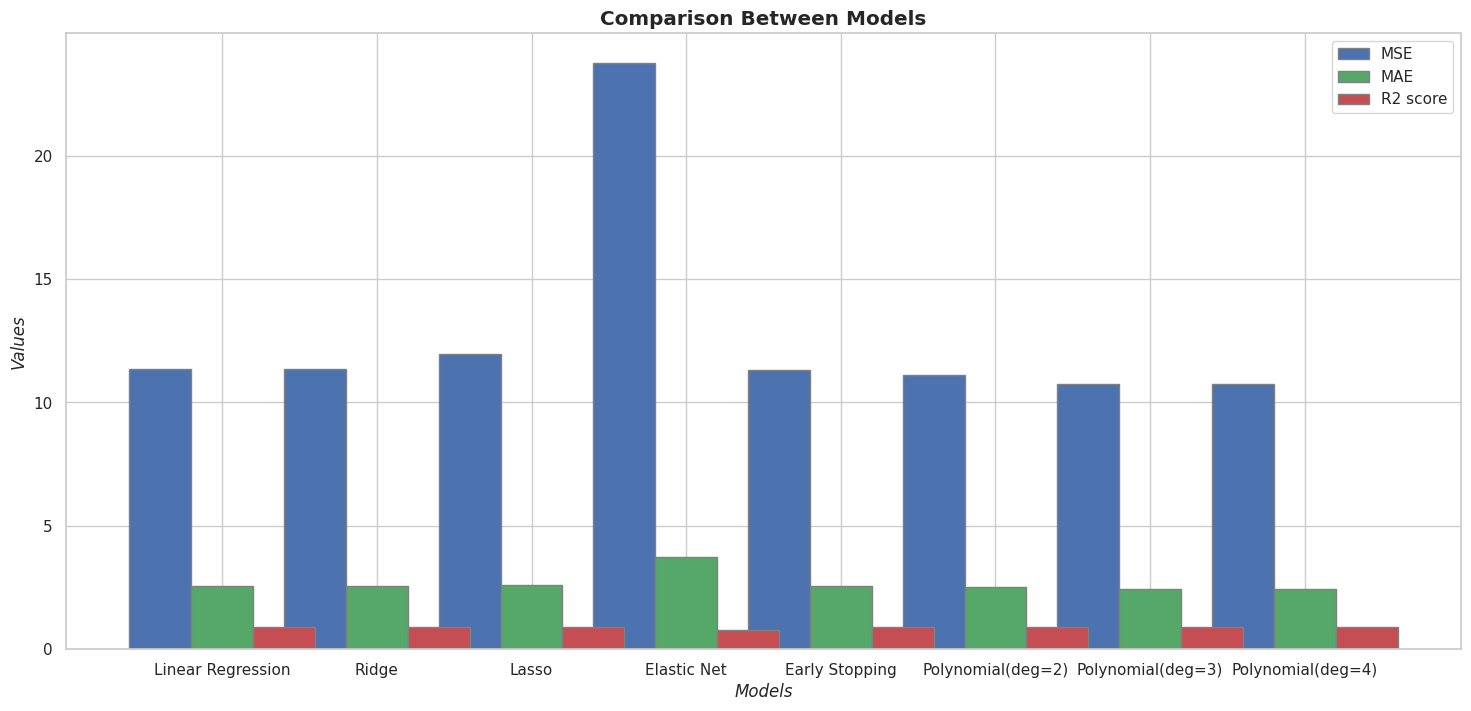

In [ ]:
fig1 , ax1 = plt.subplots(figsize=(18,8))
models=['Linear Regression' , 'Ridge' , 'Lasso' , 'Elastic Net' , 'Early Stopping' , 'Polynomial(deg=2)' , 'Polynomial(deg=3)' , 'Polynomial(deg=4)']
times=[time_lin ,time_ridge , time_lasso , time_enet , time_es , time_pdeg2 , time_pdeg3 , time_pdeg4]
bars1 = ax1.bar(models , times)
plt.title('Comparison Between Running Time',fontweight='bold', fontsize='large')
plt.xlabel("Models" ,style='italic')
plt.ylabel("Time" ,style='italic')
plt.show()
mse_all=[mse_lin , mse_ridge , mse_lasso , mse_enet , mse_sgd , mse2 , mse3 , mse4]
mae_all=[mae_lin, mae_ridge ,mae_lasso , mae_enet , mae_sgd , mae2 , mae3 , mae4]
r2_all=[r2_lin , r2_ridge , r2_lasso , r2_enet , r2_sgd , r22 , r23 , r24]
# x=np.arange(len(models))
width=0.4
r1 = np.arange(len(models))
r2 = [x + width for x in r1]
r3 = [x + width for x in r2]
plt.figure(figsize=(18, 8))
plt.bar(r1, mse_all, color='b', width=width, edgecolor='grey', label='MSE')
plt.bar(r2, mae_all, color='g', width=width, edgecolor='grey', label='MAE')
plt.bar(r3, r2_all, color='r', width=width, edgecolor='grey', label='R2 score')
plt.xlabel("Models" ,style='italic')
plt.ylabel("Values" , style='italic')
plt.xticks([r + width for r in range(len(models))], models)
plt.title('Comparison Between Models',fontweight='bold', fontsize='large')
plt.legend()
plt.show()


## 10. Conclusion
**Instruction:** Summarize the findings from the analysis, including which models performed best in terms of accuracy and computational efficiency.



 In this project, we explored various linear regression techniques to predict our target variable
 accurately. We began with simple linear regression and gradually incorporated more sophisticated
 methods, including Stochastic Gradient Descent (SGD), Mini-Batch Gradient Descent (MBGD),
 and Batch Gradient Descent (BGD). Each method was evaluated based on its convergence speed,
 computational efficiency, and prediction accuracy.
 SGD, with its ability to update weights frequently, proved to be computationally efficient for large
 datasets, albeit with some variance in the results. MBGD offered a balanced approach, combining
 the benefits of both SGD and BGD, leading to faster convergence with reduced variance. BGD,
 while computationally intensive, provided stable and consistent updates, making it suitable for
 smaller datasets.
 Additionally, we extended our analysis to polynomial regression to capture non-linear relationships
 within the data. This approach significantly improved our model’s performance, highlighting the importance of considering non-linear patterns in real-world data.
 Overall, our comprehensive analysis demonstrated that the choice of regression technique depends
 on the dataset size, computational resources, and the complexity of the underlying data patterns.
 Future work could involve exploring regularization techniques and advanced optimization algorithms to further enhance model performance.